<a href="https://colab.research.google.com/github/muhammad-usman-tech/data-analysis-tasks/blob/main/MINI_PROJECTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

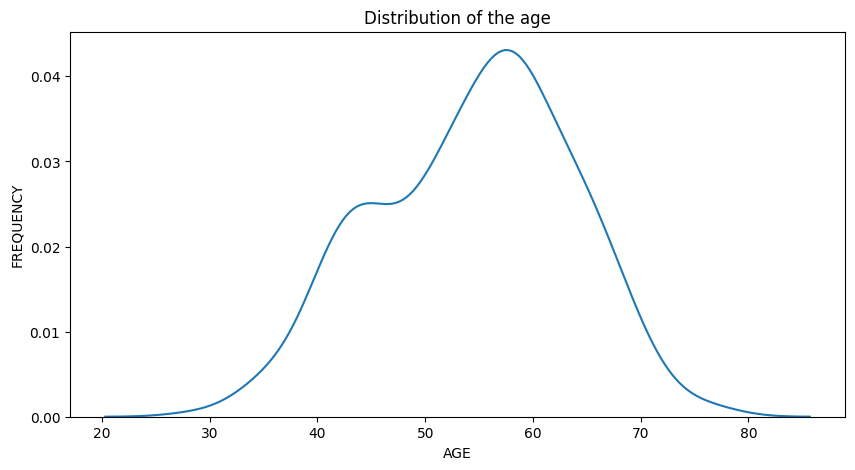

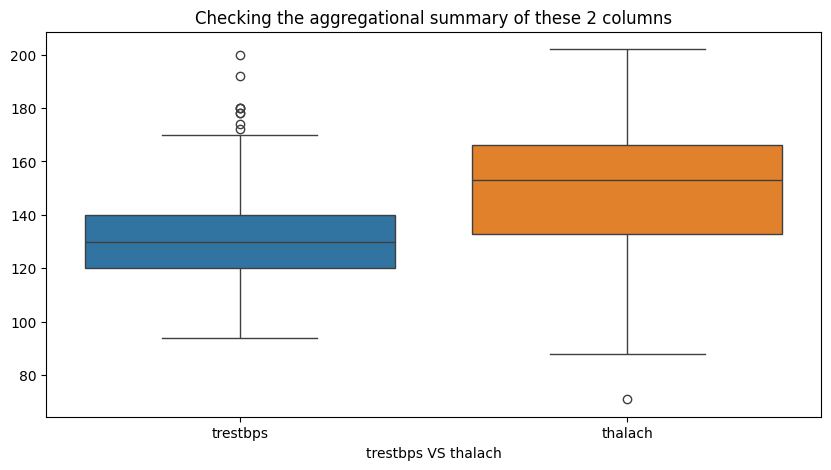

/tmp/ipykernel_2279/3616712963.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby('IS_PATIENT')['IS_PATIENT'].count() #used this technique to find the count of the yes and no to show on the barplot


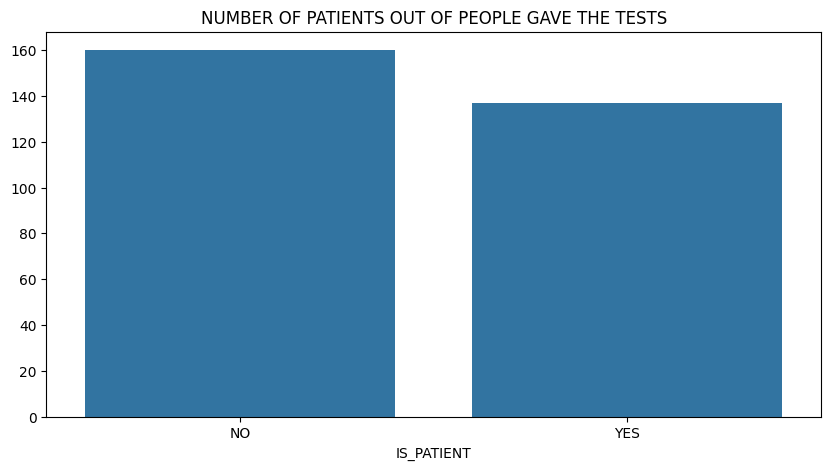

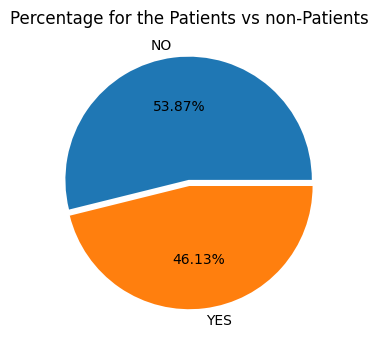

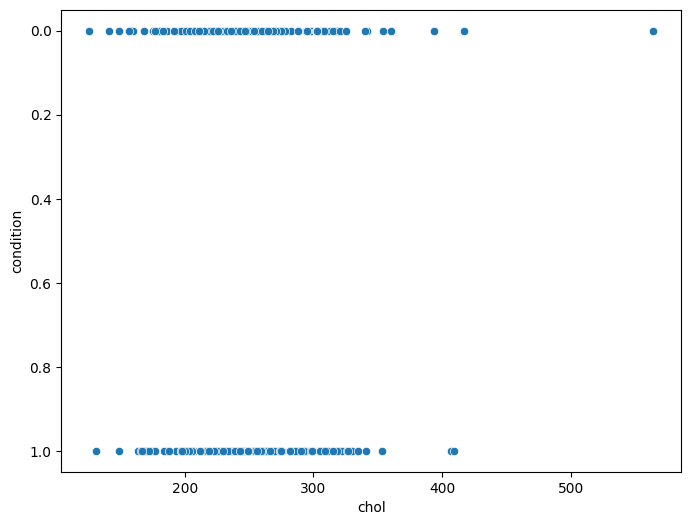

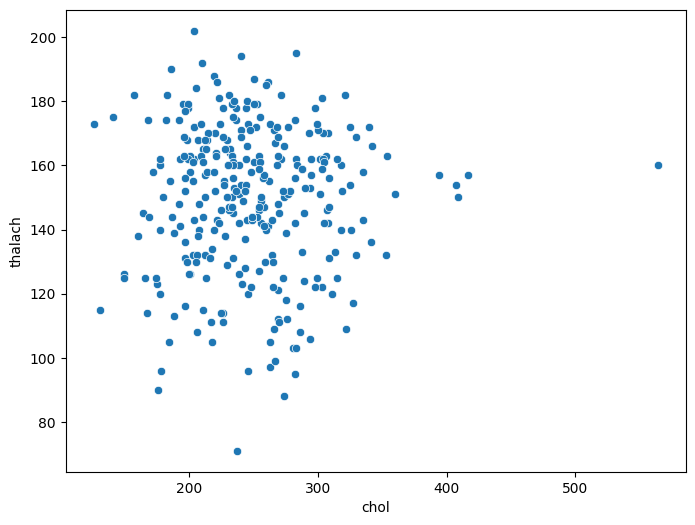

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         297 non-null    int64   
 1   sex         297 non-null    category
 2   cp          297 non-null    int64   
 3   trestbps    297 non-null    int64   
 4   chol        297 non-null    int64   
 5   fbs         297 non-null    object  
 6   restecg     297 non-null    int64   
 7   thalach     297 non-null    int64   
 8   exang       297 non-null    int64   
 9   oldpeak     297 non-null    float64 
 10  slope       297 non-null    int64   
 11  ca          297 non-null    int64   
 12  thal        297 non-null    int64   
 13  condition   297 non-null    category
 14  IS_PATIENT  297 non-null    category
dtypes: category(3), float64(1), int64(10), object(1)
memory usage: 29.2+ KB


,count
fbs,
<=120 mg,254
>120mg,43


In [ ]:
from numpy._core import numeric
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Step 1
df=pd.read_csv('/content/heart_cleveland_upload.csv')

# Step 2
df.shape
df.tail(5)

df.head(7)
df['thal'].unique()
df.describe()

# Step 3: have to do 3 things deal with the null values , duplicate values , correct the data type
# firstly dealing  the null data
null=df.isnull().sum()
# null there are 0 null values but still just find the percentage to tell or to revise the concepts by myself or checking if i remember the farmulaes
percentage=(null/len(df))*100
percentage
col_drop=percentage[percentage>=50]
df=df.drop(columns=col_drop)

# now filling (This part is not needed as there are no object columns and no nulls to fill)
# obj_columns=df.select_dtypes(include='object').columns
# df[obj_columns]=df[obj_columns].fillna(df[obj_columns].mode().iloc[0])
col_num=df.select_dtypes(include='number').columns
df[col_num]=df[col_num].fillna(df[col_num].mean())

# i have no categorical here right now so move next

# removing the duplicates

print('===============')
df.duplicated().sum() #got np.int64(0) duplicates
# but the code to remove the duplicate is the
# df=df.drop_duplicates()

# now correcting the data types and i am watching there are some columns that must be in the category not in the int
# so just converting main 2 attributes into the category(condition and the sex)
df['sex']=df['sex'].astype('category')
df['condition']=df['condition'].astype('category')

# df.info() #updated sucessfully but can also use the .replace function to convert in into the string and going to perform 1 column here
df['fbs'].unique() # got 0 and 1
df['fbs']=df['fbs'].replace({0:'<=120 mg',1:'>120mg'})

df.head()

# Step 4: uni variate so just taking the 2-3 graphs in the univariate maybe 2
# checking the distribution of the age
plt.figure(figsize=(10,5))
sns.kdeplot(df['age'])
plt.title('Distribution of the age')
plt.xlabel('AGE')
plt.ylabel('FREQUENCY')
plt.show()
# it was almost the bell curved means equally distributes no side was longer


# now checking the aggregational summary of the 2 columns using the box plot

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['trestbps','thalach']])
plt.title('Checking the aggregational summary of these 2 columns')
plt.xlabel('trestbps VS thalach')
plt.show() #here the max of the trestbp is almost 170 and it contains almost sevral strange values after its max but thalach hax max of 200 and it doesnot contains any strange value

# Step 5: bi-variate charts
# prepairing for the box plot
df['IS_PATIENT']=df['condition'].apply(lambda x: 'YES' if x==1 else 'NO')


df['IS_PATIENT']
data=df.groupby('IS_PATIENT')['IS_PATIENT'].count() #used this technique to find the count of the yes and no to show on the barplot
plt.figure(figsize=(10,5))
sns.barplot(x=data.index,y=data.values)
plt.title('NUMBER OF PATIENTS OUT OF PEOPLE GAVE THE TESTS')
plt.show()
explode=[0.05,0]
# and also making the piechart of this data that will look good (i want to say the logic of data can be used for both piechart and the pie chart)
plt.figure(figsize=(6,4))
plt.pie(data,labels=data.index,autopct='%1.2f%%',explode=explode)
plt.title('Percentage for the Patients vs non-Patients')
plt.show()

# now making the scatter chart: is chol in blood is increasinf the patient rate
plt.figure(figsize=(8,6))
sns.scatterplot(x='chol',y='condition',data=df)
plt.show() #it gave a very down straight line may be the condition is categorical thats why no good results found
# now making it with the thalach to check the pattern
plt.figure(figsize=(8,6))
sns.scatterplot(x='chol',y='thalach',data=df)
plt.show() #here dots are spread allover the graph so no they are not connected to each other

# final making the heatmap or just leave the heat map for now

#Step6:  finding the coorelation

df.info()
df.head()

df['IS_PATIENT'].value_counts()
df['fbs'].value_counts()
